In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# 1. Load Data
print("Loading datasets...")

# Changed from read_excel to read_csv
df_train = pd.read_csv('train.csv')
df_labels = pd.read_csv('train_labels.csv')

# 2. Merge on index (assuming 1-to-1 row mapping)
# The labels file has a column named 'Label'
df = pd.concat([df_train, df_labels['Label']], axis=1)

# 3. Format the Target Variable
# Problem statement: Churn = 1, Retained = -1
# We map Retained (-1) to 0 for standard binary classification
df['target'] = df['Label'].apply(lambda x: 1 if x == 1 else 0)
df = df.drop(columns=['Label'])

print(f"Data merged successfully.")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Features (including target): {df.shape[1]}")

Loading datasets...
Data merged successfully.
Total Rows: 50000
Total Features (including target): 231


Target Variable Distribution:
Retained (0): 92.66%
Churned (1):  7.34%


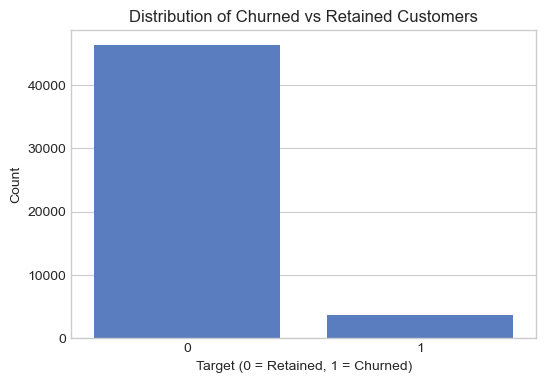

In [6]:
# Check class imbalance
target_dist = df['target'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"Retained (0): {target_dist[0]:.2f}%")
print(f"Churned (1):  {target_dist[1]:.2f}%")

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Distribution of Churned vs Retained Customers', fontsize=12)
plt.xlabel('Target (0 = Retained, 1 = Churned)')
plt.ylabel('Count')
plt.show()

Total features with missing values: 211 out of 230


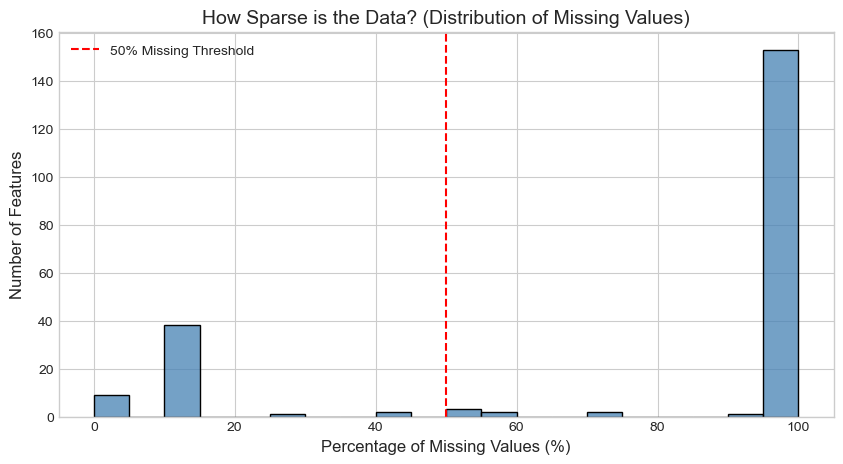

In [8]:
# Calculate percentage of missing values per column
missing_percentages = df.isnull().mean() * 100
missing_stats = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print(f"Total features with missing values: {len(missing_stats)} out of {df.shape[1]-1}")

# Plot the distribution of missingness
plt.figure(figsize=(10, 5))
sns.histplot(missing_stats, bins=20, kde=False, color='steelblue')
plt.title('How Sparse is the Data? (Distribution of Missing Values)', fontsize=14)
plt.xlabel('Percentage of Missing Values (%)', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.axvline(x=50, color='red', linestyle='--', label='50% Missing Threshold')
plt.legend()

# ADD THIS LINE RIGHT BEFORE plt.show()
plt.savefig("missingness_plot.png", bbox_inches='tight', dpi=300)

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

print("Starting Feature Engineering...")
df_processed = df.copy()

# 1. Row-wise missingness
df_processed['total_missing_features'] = df.drop(columns=['target']).isnull().sum(axis=1)

# 2. Identify highly sparse columns (missing > 50%)
high_missing_cols = missing_percentages[missing_percentages > 50].index

# 3. Create explicit binary indicators for the sparse columns
for col in high_missing_cols:
    df_processed[f'{col}_is_missing'] = df_processed[col].isnull().astype(int)

# --- THE FIX: Convert 'object' columns to 'category' ---
print("Converting object types to category for LightGBM...")
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        df_processed[col] = df_processed[col].astype('category')
# -------------------------------------------------------

print(f"Added missingness indicators. New shape: {df_processed.shape}")

# Train/Test Split
X = df_processed.drop(columns=['target'])
y = df_processed['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data successfully split for modeling.")

Starting Feature Engineering...
Converting object types to category for LightGBM...
Added missingness indicators. New shape: (50000, 393)
Data successfully split for modeling.


In [11]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------------------

Training LightGBM Model...


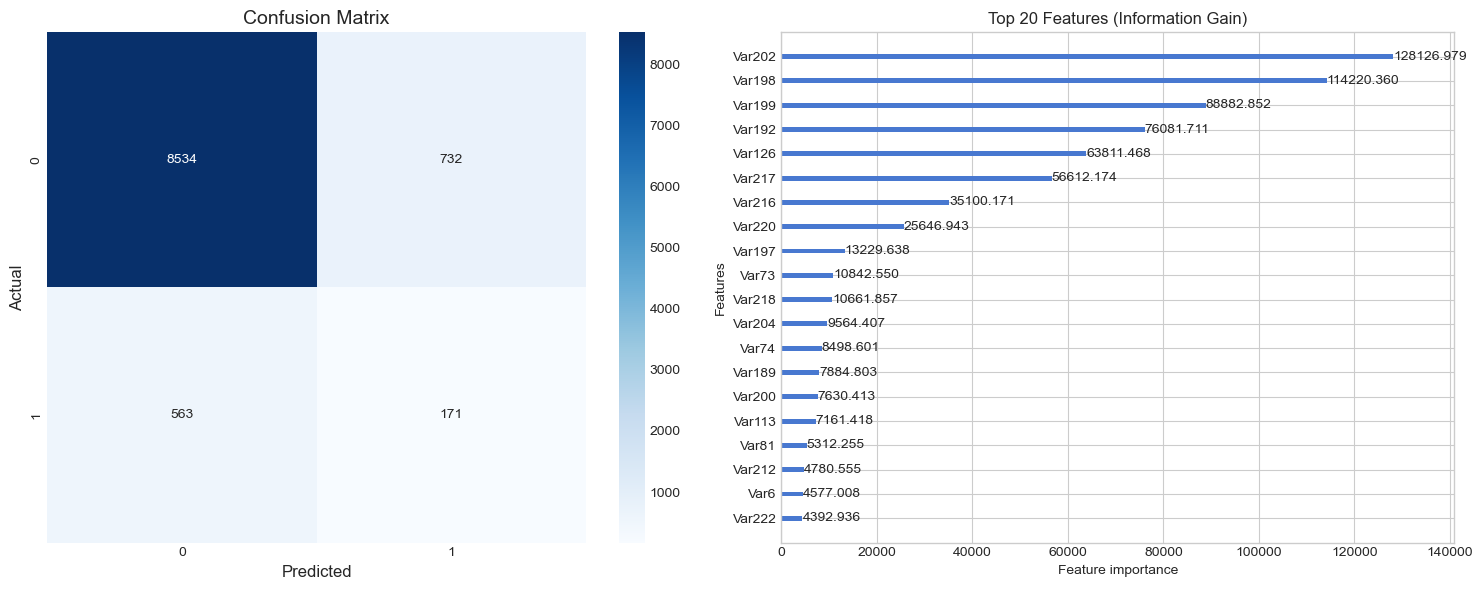


--- Model Performance Metrics ---
PR-AUC Score: 0.1402
F2 Score (Prioritizes Recall): 0.2227

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      9266
           1       0.19      0.23      0.21       734

    accuracy                           0.87     10000
   macro avg       0.56      0.58      0.57     10000
weighted avg       0.88      0.87      0.88     10000



In [15]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, fbeta_score

print("Training LightGBM Model...")

# Calculate the weight for the minority class to handle the 7.3% imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=pos_weight, 
    max_depth=5,                 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    importance_type='gain',
    verbose=-1
)

# Fit the model
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# --- METRICS & PLOTS ---

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# 2. Feature Importance (Top 20)
lgb.plot_importance(clf, max_num_features=20, importance_type='gain', ax=axes[1], title='Top 20 Features (Information Gain)')

plt.tight_layout()
plt.savefig("model_evaluation.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Print Advanced Metrics
pr_auc = auc(*precision_recall_curve(y_test, y_proba)[:2][::-1])
f2 = fbeta_score(y_test, y_pred, beta=2)

print("\n--- Model Performance Metrics ---")
print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"F2 Score (Prioritizes Recall): {f2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))